###  This notebook is used to optimize Hyperparameters of GradientBoostingRegressor() predicting SRP absolute concentrations:

In [1]:
# load required moduls:

# load required moduls:
# pandas is used for data manipulation:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn import metrics
from numpy import mean
from numpy import std
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

In [ ]:
# define the output folder path:

output_folder = '../../../output_data/ML_analysis/hyperparameter_settings'

# Check if the folder exists, if not, create it:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)


#### 1. import data:

In [ ]:
nutrient_export_data = pd.read_csv('../../../output_data/input_ML_learning_temp/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [3]:
#nutrient_export_data.info()

## Prepare the data for the machine learning models:

1. Split data into features and targets
2. Convert data frame to arrays 
3. Split data into training and test set

1. Function to prepare input data: split data into target and features and convert to arrays: 

In [4]:

def create_input_ML(data, target_var):

    # create array with exported nutrient values, which are our target values, we want to predict 
    target = np.array(nutrient_export_data[target_var])


    # remove the labels from the features df:

    features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
    #features = nutrient_export_data.filter(items=selected_features)

    #select columns by index: 
    features= features.iloc[:,:]
    features.columns

    # save feature list for later use:
    feature_list = list(features.columns)

    # convert to numpy array:
    features = np.array(features)

    return target, features, feature_list

### Apply create_input_ML function: set data and target_var

In [5]:
# choose target var: "n_imbal", "p_imbal" or "c_imbal":
target_var = 'median_SRP'

# data:
data = nutrient_export_data

In [6]:
target, features, feature_list = create_input_ML(data = data, target_var = target_var)

In [7]:
len(feature_list)

33

### Split data into training and testing set: 

### set test_size and random_state

In [8]:
# test size: usually 0.2 or 0.25:
test_size = 0.2
#set random_state:
random_state = 41 # before I used random_state=41


In [9]:

# using Skicit-learn to split data into training and testing sets:
from sklearn.model_selection import train_test_split

train_features, test_features, train_targets, test_targets = train_test_split(features, target, test_size = test_size, random_state = random_state) 



Check data structure: targets and features should have same length in training and test set:

In [10]:
print('Training Features Shape:', train_features.shape)
print('Training targets Shape:', train_targets.shape)
print('Testing Features Shape:', test_features.shape)
print('Testing targets Shape:', test_targets.shape)

Training Features Shape: (2796, 33)
Training targets Shape: (2796,)
Testing Features Shape: (700, 33)
Testing targets Shape: (700,)


### Box-Cox transformation of training and testing targets:

In [11]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')

# Reshape train_targets to 2D if it's 1D
if len(train_targets.shape) == 1:
    train_targets2 = np.reshape(train_targets, (-1, 1))

# Fit the transformer to the training data
# This learns the best lambda value for each feature
pt.fit(train_targets2)

# Transform the training data using the learned lambda values
train_targets_transformed_bc = pt.transform(train_targets2)
# convert back to 1D format
train_targets_transformed_bc = train_targets_transformed_bc.ravel()

# Transform the test data using the same lambda values
# Reshape test_targets to 2D if it's 1D
if len(test_targets.shape) == 1:
    test_targets2 = np.reshape(test_targets, (-1, 1))

test_targets_transformed_bc = pt.transform(test_targets2)
test_targets_transformed_bc = test_targets_transformed_bc.ravel()

### Also log_transform the data:

In [12]:
train_targets_transformed_log = np.log1p(train_targets)
test_targets_transformed_log = np.log1p(test_targets)

### Plot data and transformed data testing and training set:

C:\Users\bartusch\AppData\Local\Temp\14\ipykernel_41476\3265750013.py:17: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


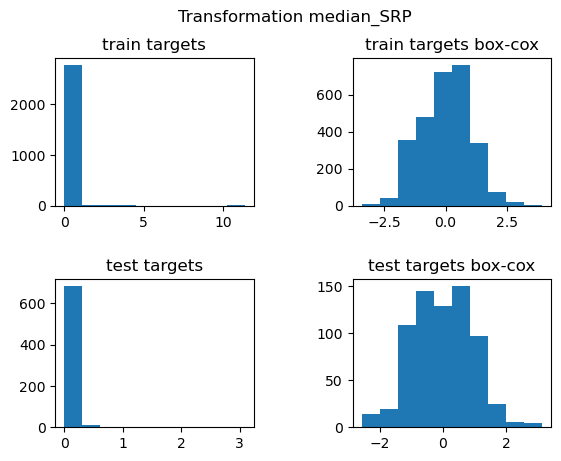

In [13]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2)
# Plot data on each subplot
axs[0, 0].hist(train_targets)
axs[0, 0].set_title('train targets')

axs[0, 1].hist(train_targets_transformed_bc)
axs[0, 1].set_title('train targets box-cox')

axs[1, 0].hist(test_targets)
axs[1, 0].set_title('test targets')

axs[1, 1].hist(test_targets_transformed_bc)
axs[1, 1].set_title('test targets box-cox')
fig.subplots_adjust(hspace=0.5, wspace=0.5)
fig.suptitle(f'Transformation {target_var}')
fig.show()

### Import model functions from sklearn:

In [14]:
# import models
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics


# Fit Boosting regression tree and random forest model: first with default parameters:

In [15]:
def_parms_brt = {
    "n_estimators": 7000,
    "max_depth": 9,
    "min_samples_split": 5,
    "learning_rate": 0.001, # before i had 0.005
    "loss": "squared_error",
    "subsample": 0.5,
}


def_parms_rf = {
    "n_estimators": 6000,
    "max_depth": 4,
}

model = "brt"

cross_val = RepeatedKFold(n_splits=2, n_repeats=2, random_state=1)


### fit Gradient Boosting Regressor with default parameters: 

In [16]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from datetime import datetime
import os

def run_model_def_parms(model, parms, target_var, train_features, test_features, train_targets, test_targets, cross_val):
    
    if target_var == "n_imbal":
        comp = "DIN"
    if target_var == "p_imbal":
        comp = "SRP"
    if target_var == "c_imbal":
        comp = "OC"

    if target_var == 'median_DIN':
        comp = "DIN"
    if target_var == 'median_SRP':
        comp = "SRP"
    if target_var == 'median_DOC_TOC_bioav':
        comp = "OC"
    
    
    if model == "brt":
        ml_model = GradientBoostingRegressor(**parms,  random_state = 5)
    if model == "rf":
        ml_model = RandomForestRegressor(**parms)

    
    #n_scores = cross_val_score(ml_model, train_features, train_targets, scoring='r2', cv=cross_val, n_jobs=4, error_score='raise')
    #print('Cross validation R2: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))


    # Train the model on all training data: 
    ml_model.fit(train_features, train_targets);

    # evaluate model with test data:
    predictions = ml_model.predict(test_features)

    # pred on training data: 
    pred_train = ml_model.predict(train_features)

    if model == "brt":
        test_score = np.zeros((parms["n_estimators"],), dtype=np.float64)
        for i, y_pred in enumerate(ml_model.staged_predict(test_features)):
            test_score[i] = mean_squared_error(test_targets, y_pred)

        fig = plt.figure(figsize=(6, 6))
        plt.subplot(1, 1, 1)
        plt.title("Deviance")
        plt.plot(
            np.arange(parms["n_estimators"]) + 1,
            ml_model.train_score_,
            "b-",
            label="Training Set Deviance",
            )
        plt.plot(
            np.arange(parms["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
            )
        plt.legend(loc="upper right")
        plt.xlabel("Boosting Iterations")
        plt.ylabel("Deviance")
        fig.tight_layout()
        plt.show()

    
    # plot predictions on training data and testing data:

    # first training data:
    
    plt.scatter(train_targets, pred_train) 
    plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
    plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
    plt.title(f" Training data model: {str(model)} predicting {target_var}", fontsize=14)
    r2 = r2_score(train_targets, pred_train)
    # add line of linear model
    
    plt.plot(test_targets, test_targets, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
    plt.legend()
    plt.show()
            

    
    
    #now testing data:
    plt.scatter(test_targets, predictions) 
    plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
    plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
    plt.title(f" Testing data model: {str(model)} predicting {target_var}", fontsize=14)
    r2 = r2_score(test_targets, predictions)
    # add line of linear model
    
    plt.plot(test_targets, test_targets, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
    plt.legend()
    plt.show()

    r2_test = r2_score(test_targets, predictions)
    r2_test
    
    MAPE = mean_absolute_percentage_error(test_targets, predictions)
    print(f"Model: {str(model)} --> MAPE = {MAPE*100.0:.2f}")
    
    mse = mean_squared_error(test_targets, ml_model.predict(test_features))
    print("The mean squared error (MSE) on test set: {:.4f}".format(mse))
    
    mae = mean_absolute_error(test_targets, ml_model.predict(test_features))
    print("The mean absolute error (MAE) on test set: {:.4f}".format(mae))

    # return fitted model:
    return ml_model



    

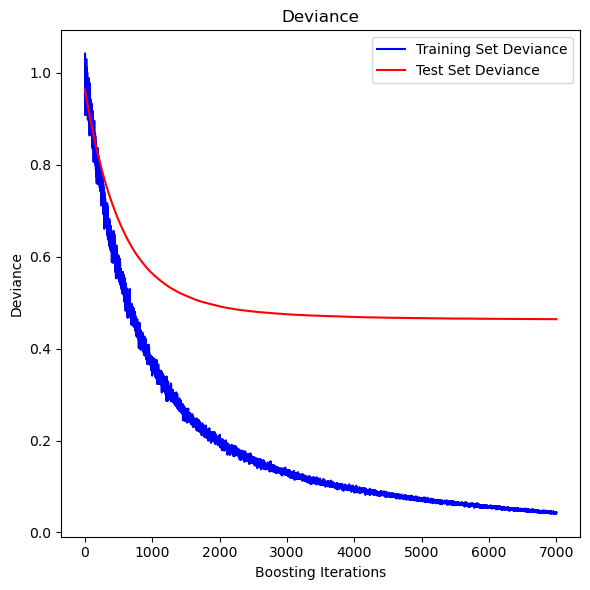

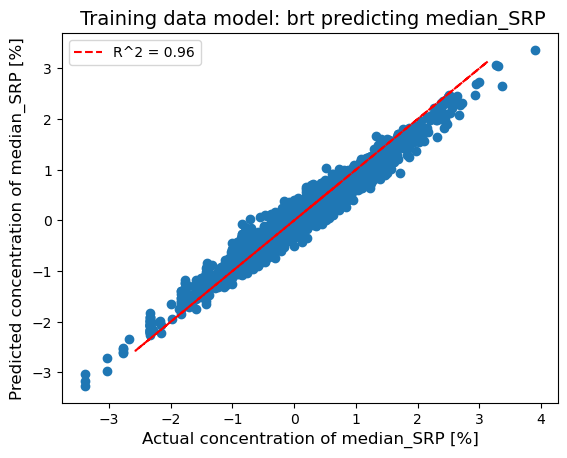

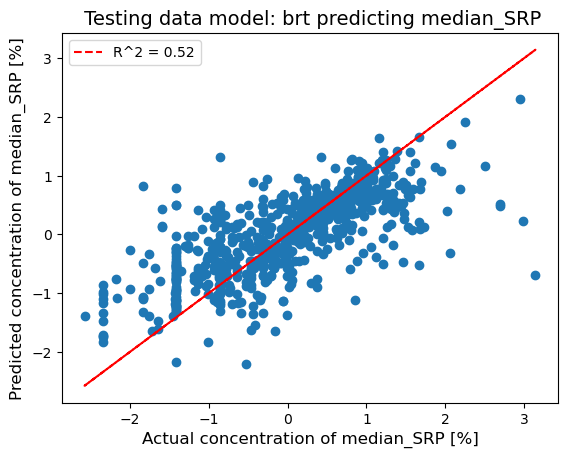

Model: brt --> MAPE = 549.80
The mean squared error (MSE) on test set: 0.4641
The mean absolute error (MAE) on test set: 0.4952


In [17]:
model_fitted = run_model_def_parms(model = model, target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc, cross_val = cross_val, parms = def_parms_brt)

### Define a function to write infos of fitted model to csv file:

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append('../')
from functions_ml_analysis import info_fitted_model_to_csv  

In [19]:
info_fitted_model_to_csv(fitted_model = model_fitted, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: base parameter absolute SRP concentrations 


False


### Compare the model with log-transformed target variables:

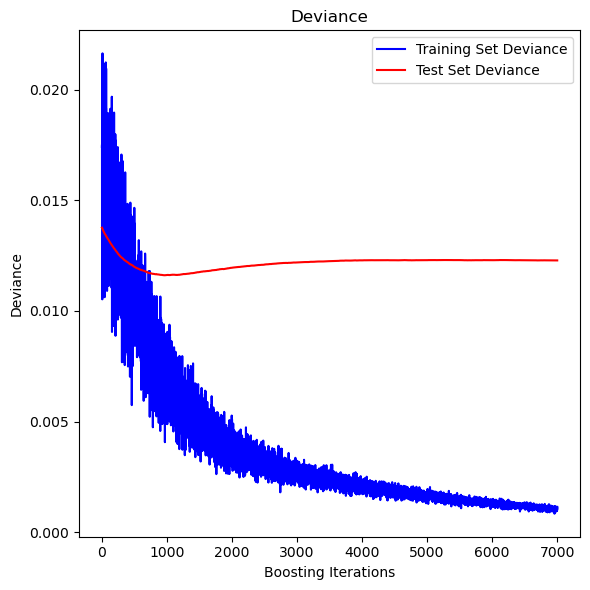

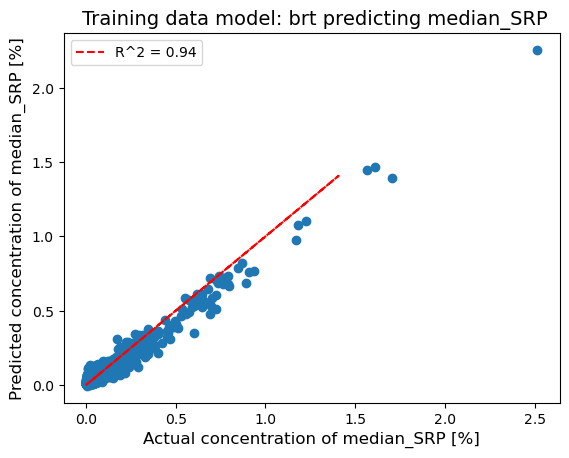

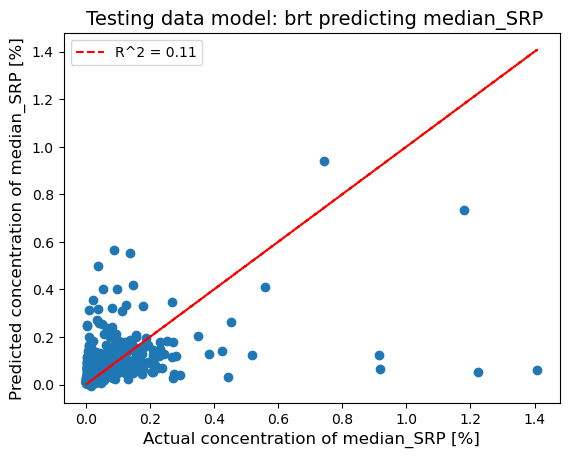

Model: brt --> MAPE = 228.93
The mean squared error (MSE) on test set: 0.0123
The mean absolute error (MAE) on test set: 0.0482


In [20]:
model_fitted = run_model_def_parms(model = model, target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets_transformed_log, test_targets = test_targets_transformed_log, cross_val = cross_val, parms = def_parms_brt)

In [21]:
info_fitted_model_to_csv(fitted_model = model_fitted, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_log, test_targets = test_targets_transformed_log)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: log


log
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: base parameters log transformed strong overfitting


False


### Fit the model with same parameters as above but use early stopping if loss is not improving by adding more trees:

In [22]:
gbm_early_stopping = GradientBoostingRegressor(
    **def_parms_brt,
    random_state = 5,
    validation_fraction=0.1,
    n_iter_no_change= int(def_parms_brt['n_estimators']* 0.1), #use 10 percent of n_estimators
)

gbm_early_stopping.fit(train_features, train_targets_transformed_bc)

preds_test = gbm_early_stopping.predict(test_features)
print(f"R2_score{r2_score(test_targets_transformed_bc, preds_test):2f}")
print(f"MAPE = {mean_absolute_percentage_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MSE = {mean_squared_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MAE ={mean_absolute_error(test_targets_transformed_bc, preds_test):2f}")

R2_score0.517037
MAPE = 5.497865
MSE = 0.465308
MAE =0.502294


In [23]:
gbm_early_stopping.n_estimators_

7000

In [24]:
info_fitted_model_to_csv(fitted_model = gbm_early_stopping, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: early stopping using base parameters, but did not stop


True


### Apply parameter tuning using RandomizedSearchCV():

In [25]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform

# Define the model: 
model = GradientBoostingRegressor(random_state = 5) 


# define the evaluation procedure
from sklearn.model_selection import RepeatedKFold
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)


# define scoring functions:

scoring = {"R2": "r2", "MAE": "neg_mean_absolute_error"}


# set parameter ranges
params_random = {'max_depth':  np.arange(3, 14), 
         #'min_samples_leaf': np.arange(2, 11),
          'max_features': np.arange(2, 33),
         "subsample": np.arange(0.5,1, 0.1),
         "learning_rate":  loguniform(a=1e-3, b=1e0), #np.linspace(start = 0.001, stop = 0.4, num = 1200),
         "n_estimators":np.arange(1000, 9000, 25)}

gridrandom = RandomizedSearchCV(estimator = model,
                                param_distributions = params_random,
                                cv= cv, 
                                verbose= 10, 
                                n_jobs= 60,
                                refit = "R2",
                                scoring = scoring,
                                return_train_score=True,
                                n_iter = 2500,
                                )
                                

# summarize the best score and configuration
#print("Best: %f using %s" % (gridsearch_result.best_score_, gridsearch_result.best_params_)) # summarize all scores that were evaluated
#means = gridsearch_result.cv_results_['mean_test_score']
#stds = grid_result.cv_results_['std_test_score']
#params = grid_result.cv_results_['params']
#for mean, stdev, param in zip(means, stds, params):
 #   print("%f (%f) with: %r" % (mean, stdev, param))

In [26]:
params_random

{'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
 'subsample': array([0.5, 0.6, 0.7, 0.8, 0.9]),
 'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x25dca77f590>,
 'n_estimators': array([1000, 1025, 1050, 1075, 1100, 1125, 1150, 1175, 1200, 1225, 1250,
        1275, 1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500, 1525,
        1550, 1575, 1600, 1625, 1650, 1675, 1700, 1725, 1750, 1775, 1800,
        1825, 1850, 1875, 1900, 1925, 1950, 1975, 2000, 2025, 2050, 2075,
        2100, 2125, 2150, 2175, 2200, 2225, 2250, 2275, 2300, 2325, 2350,
        2375, 2400, 2425, 2450, 2475, 2500, 2525, 2550, 2575, 2600, 2625,
        2650, 2675, 2700, 2725, 2750, 2775, 2800, 2825, 2850, 2875, 2900,
        2925, 2950, 2975, 3000, 3025, 3050, 3075, 3100, 3125, 3150, 3175,
        3200, 3225, 3250, 

In [27]:
%%time
# search_result = 
gridrandom.fit(train_features, train_targets_transformed_bc)

Fitting 30 folds for each of 2500 candidates, totalling 75000 fits
CPU times: total: 4min 38s
Wall time: 1d 19h 19min 26s


RandomizedSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
                   estimator=GradientBoostingRegressor(random_state=5),
                   n_iter=2500, n_jobs=60,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000025DCA77F590>,
                                        'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
                                        'max_features': array([ 2,  3,  4,  5,  6,  7...
       7875, 7900, 7925, 7950, 7975, 8000, 8025, 8050, 8075, 8100, 8125,
       8150, 8175, 8200, 8225, 8250, 8275, 8300, 8325, 8350, 8375, 8400,
       8425, 8450, 8475, 8500, 8525, 8550, 8575, 8600, 8625, 8650, 8675,
       8700, 8725, 8750, 8775, 8800, 8825, 8850, 8875, 8900, 8925, 8950,
       8975]),
                                        'subsample': array([0.5, 0.6, 0.7, 0.8, 0.9])},
                   refit='R2', return_train_score=True,
                   scoring={'MAE': 'neg_mean_absolute_error', 'R2': 'r2'},
                   verbose=10)

In [33]:
print(gridrandom.best_params_)
print(gridrandom.best_score_)

{'learning_rate': 0.0014628853574732998, 'max_depth': 10, 'max_features': 4, 'n_estimators': 6125, 'subsample': 0.5}
0.5315063692532909


In [34]:
gridrandom.get_params

<bound method BaseEstimator.get_params of RandomizedSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
                   estimator=GradientBoostingRegressor(random_state=5),
                   n_iter=2500, n_jobs=60,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000025DCA77F590>,
                                        'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
                                        'max_features': array([ 2,  3,  4,  5,  6,  7...
       7875, 7900, 7925, 7950, 7975, 8000, 8025, 8050, 8075, 8100, 8125,
       8150, 8175, 8200, 8225, 8250, 8275, 8300, 8325, 8350, 8375, 8400,
       8425, 8450, 8475, 8500, 8525, 8550, 8575, 8600, 8625, 8650, 8675,
       8700, 8725, 8750, 8775, 8800, 8825, 8850, 8875, 8900, 8925, 8950,
       8975]),
                                        'subsample': array([0.5, 0.6, 0.7, 0.8, 0.9])},
                   refit='R2',

In [35]:
# apply optimized model:

preds_test = gridrandom.predict(test_features)

preds_train = gridrandom.predict(train_features)

In [36]:
from sklearn.metrics import r2_score
r2_score(test_targets_transformed_bc, preds_test)

0.5304023791110111

In [37]:

print(f"R2_score{r2_score(test_targets_transformed_bc, preds_test):2f}")
print(f"MAPE = {mean_absolute_percentage_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MSE = {mean_squared_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MAE ={mean_absolute_error(test_targets_transformed_bc, preds_test):2f}")

R2_score0.530402
MAPE = 5.687847
MSE = 0.452431
MAE =0.485874


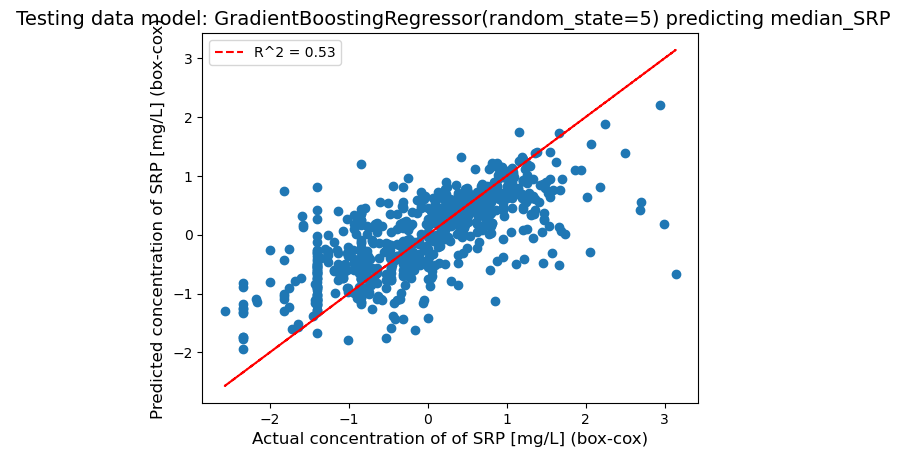

In [38]:
plt.scatter(test_targets_transformed_bc, preds_test) 
plt.xlabel(f"Actual concentration of of SRP [mg/L] (box-cox)", fontsize=12)
plt.ylabel(f"Predicted concentration of SRP [mg/L] (box-cox)", fontsize=12)
plt.title(f" Testing data model: {str(model)} predicting {target_var}", fontsize=14)
r2 = r2_score(test_targets_transformed_bc, preds_test)
 # add line of linear model
    
plt.plot(test_targets_transformed_bc, test_targets_transformed_bc, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
plt.legend()
plt.show()

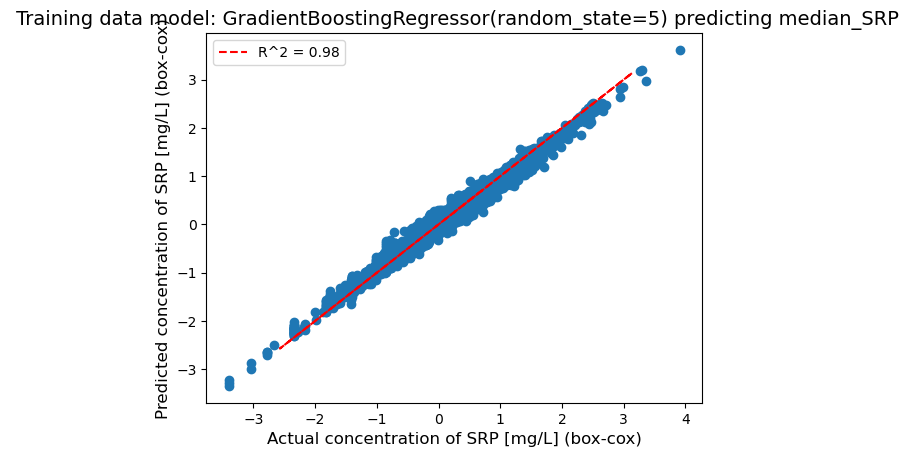

In [39]:
plt.scatter(train_targets_transformed_bc, preds_train) 
plt.xlabel(f"Actual concentration of SRP [mg/L] (box-cox)", fontsize=12)
plt.ylabel(f"Predicted concentration of SRP [mg/L] (box-cox)", fontsize=12)
plt.title(f" Training data model: {str(model)} predicting {target_var}", fontsize=14)
r2 = r2_score(train_targets_transformed_bc, preds_train)
# add line of linear model
    
plt.plot(test_targets_transformed_bc, test_targets_transformed_bc, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
plt.legend()
plt.show()
            

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append('../')
from functions_ml_analysis import info_fitted_model_to_csv  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
info_fitted_model_to_csv(fitted_model = gridrandom, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: randomizedSearchCV SRP absolute box cox transformed


True


### Now calculate importances of factors:

In [331]:
# create array with exported nutrient values, which are our target values, we want to predict 
#target = np.array(nutrient_export_data['c_imbal'])
target = nutrient_export_data[target_var]

# remove the labels from the features df:

features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
#features = nutrient_export_data.filter(items=selected_features)

#select columns by index: 
features= features.iloc[:,0:43]
features.columns

# save feature list for later use:
feature_list = list(features.columns)


In [42]:
params = {'learning_rate': 0.0014628853574732998, 'max_depth': 10, 'max_features': 4, 'n_estimators': 6125, 'subsample': 0.5}
brt = GradientBoostingRegressor(**params)
brt.fit(train_features, train_targets_transformed_bc)

GradientBoostingRegressor(learning_rate=0.0014628853574732998, max_depth=10,
                          max_features=4, n_estimators=6125, subsample=0.5)

In [43]:
pred_test_test = brt.predict(test_features)
r2_score(test_targets_transformed_bc, pred_test_test)

0.5329996914074454

In [44]:
params_optimum ={'learning_rate': 0.0014628853574732998, 'max_depth': 10, 'max_features': 4, 'n_estimators': 6125, 'subsample': 0.5}
 
brt_model = GradientBoostingRegressor()

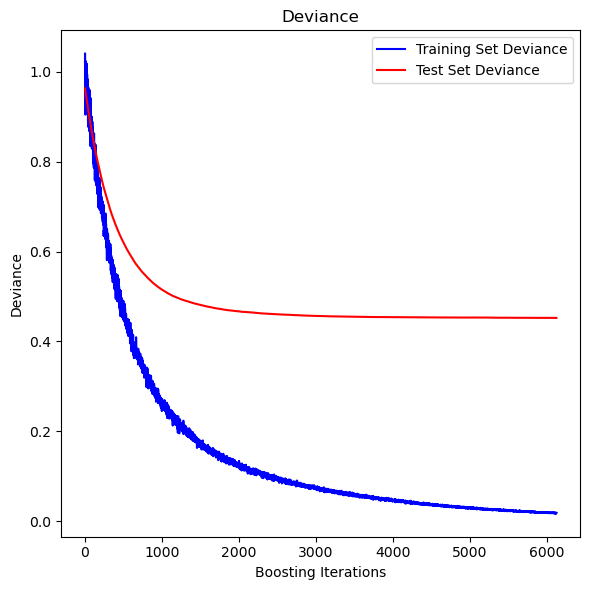

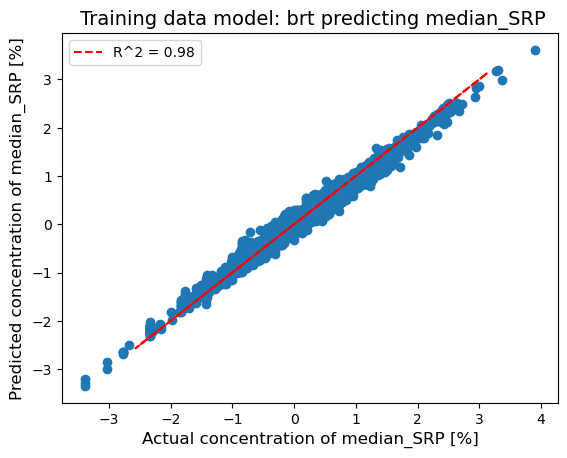

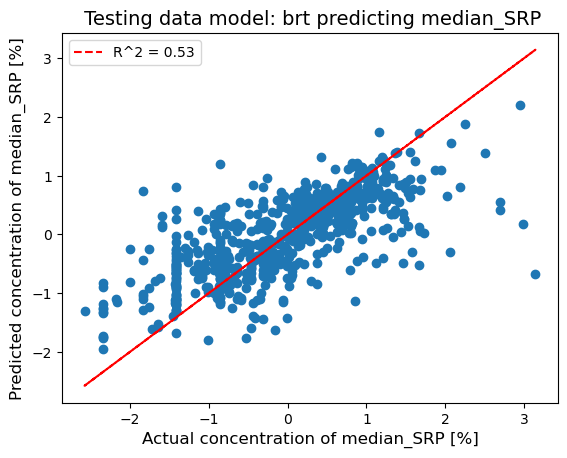

Model: brt --> MAPE = 568.78
The mean squared error (MSE) on test set: 0.4524
The mean absolute error (MAE) on test set: 0.4859


GradientBoostingRegressor(learning_rate=0.0014628853574732998, max_depth=10,
                          max_features=4, n_estimators=6125, random_state=5,
                          subsample=0.5)

In [45]:
run_model_def_parms(model = "brt", target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc, cross_val = cross_val, parms = params_optimum)

Feature importances:

In [46]:
from sklearn.inspection import permutation_importance

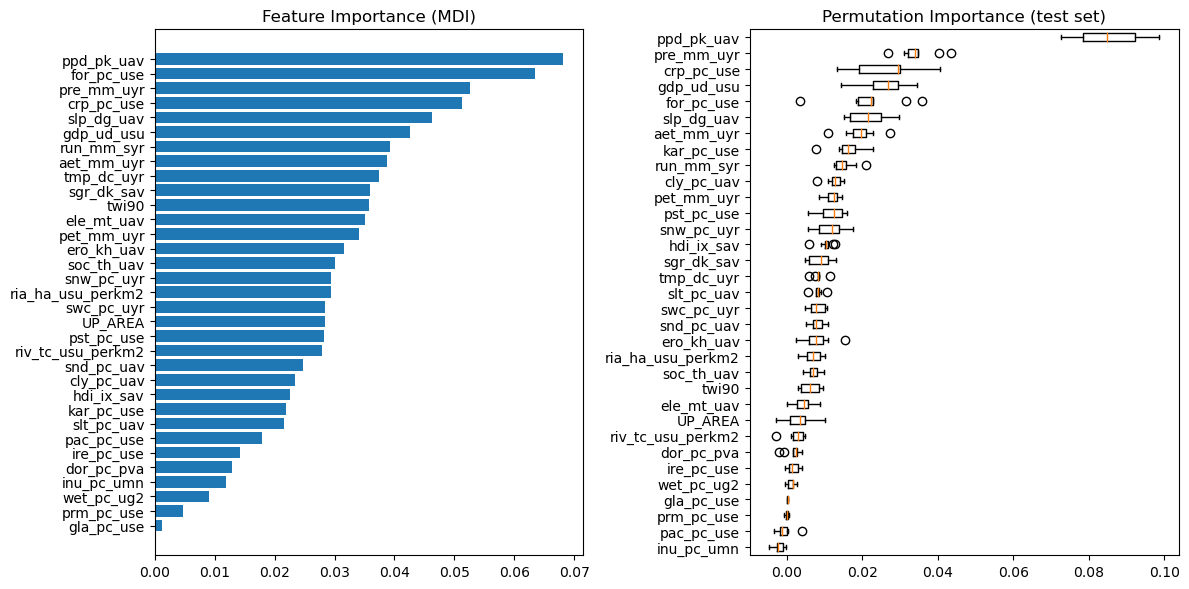

In [47]:
feature_importance = brt.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(feature_list)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    brt, test_features, test_targets_transformed_bc, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(feature_list)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

### Now fit optimized model with early stopping:

In [48]:
params ={'learning_rate': 0.0014628853574732998, 'max_depth': 10, 'max_features': 4, 'n_estimators': 6125, 'subsample': 0.5}
brt_early_stop = GradientBoostingRegressor(**params, validation_fraction = 0.1, n_iter_no_change = 10)
brt_early_stop.fit(train_features, train_targets_transformed_bc)

GradientBoostingRegressor(learning_rate=0.0014628853574732998, max_depth=10,
                          max_features=4, n_estimators=6125,
                          n_iter_no_change=10, subsample=0.5)

In [49]:
preds_train_earlys = brt_early_stop.predict(train_features)
preds_test_earlys = brt_early_stop.predict(test_features)

In [50]:
r2_score(train_targets_transformed_bc, preds_train_earlys)

0.7874660641360927

In [51]:
r2_score(test_targets_transformed_bc, preds_test_earlys)

0.49771613903433354

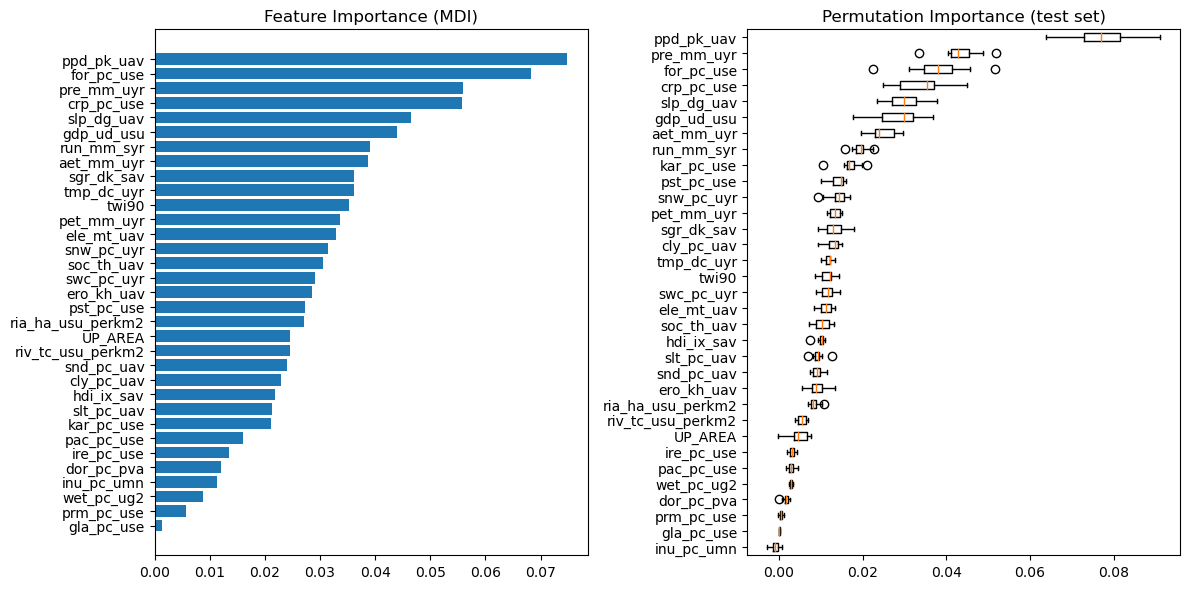

In [52]:
feature_importance = brt_early_stop.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(feature_list)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    brt_early_stop, test_features, test_targets_transformed_bc, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(feature_list)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()